#### **Prerequisites**

In the previous notebook, we built a **Linear Regression** model for predicting a continuous target.

In this notebook, we will use the same student performance dataset to build a **Logistic Regression** model for binary classification.

We will:

- Create a binary classification target from `marks`
- Select the input features
- Split the data into training and testing sets
- Preprocess numerical and categorical features
- Build a Logistic Regression pipeline
- Train the model
- Make predictions
- Evaluate the classification performance
- Save and reload the complete Machine Learning pipeline

The notebook is designed to be **self-contained**, so the required variables and preprocessing steps are recreated here rather than relying on previous notebook execution.

#### **Import Required Libraries**

We will use the following Python libraries and tools:

- `pandas` → load and work with tabular data
- `numpy` → numerical operations and verification
- `train_test_split` → divide data into training and testing sets
- `ColumnTransformer` → apply different preprocessing methods to different feature types
- `OneHotEncoder` → convert categorical features into numerical form
- `StandardScaler` → standardize numerical features
- `Pipeline` → combine preprocessing and the Logistic Regression model
- `LogisticRegression` → build the binary classification model
- Classification metrics → evaluate model performance
- `joblib` → save and load the trained Machine Learning pipeline

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../datasets/cleaned/student_performance_cleaned.csv")

#### **1. Create the Binary Target Variable**

Logistic Regression is a **classification algorithm**.

Our original target variable, `marks`, is a continuous numerical value. Therefore, it is suitable for a regression problem.

For this notebook, we will convert `marks` into a **binary classification target** called `pass`.

We will use the following rule:

- **`marks >= 80` → `pass = 1`**
- **`marks < 80` → `pass = 0`**

Therefore:

- `1` represents **Pass**
- `0` represents **Not Pass**

This changes our Machine Learning task from predicting an exact mark to predicting one of two possible classes.

In [3]:
# Create a Binary Target Variable

df["pass"] = (df["marks"] >= 80).astype(int)

df[["marks", "pass"]].head()

,marks,pass
0,67.0,0
1,77.0,0
2,70.0,0
3,71.0,0
4,82.0,1


#### **2. Select Input Features**

We now define the input features (`X`) and target variable (`y`).

The target variable is `pass`, so it must not be included among the input features.

We also exclude identifying fields and fields that are not being used as predictors in this model.

The selected features will be used to predict whether a student passes or does not pass.

In [4]:
# Select Input Features

feature_columns = [
    "age",
    "semester",
    "attendance_percentage",
    "tuition_fee",
    "department",
    "gender",
    "scholarship"
]

X = df[feature_columns].copy()
y = df["pass"]

#### **3. Identify Numerical and Categorical Features**

Machine Learning datasets can contain different types of input features.

- **Numerical features** contain numerical values and may require scaling.
- **Categorical features** contain categories and must be converted into numerical representations.

We will process these two groups separately using a `ColumnTransformer`.

##### **Numerical Features**

Numerical features will be standardized using `StandardScaler`.

##### **Categorical Features**

Categorical features will be converted into numerical features using `OneHotEncoder`.

In [5]:
# Define Numerical and Categorical Features

numerical_features = [
    "age",
    "semester",
    "attendance_percentage",
    "tuition_fee"
]

categorical_features = [
    "department",
    "gender",
    "scholarship"
]

#### **4. Train-Test Split**

Before preprocessing the features, we divide the dataset into training and testing sets.

We will use:

- **80% of the data for training**
- **20% of the data for testing**

The training data is used to learn the preprocessing parameters and train the Logistic Regression model.

The testing data is kept separate and is used only to evaluate the trained model.

For classification, we use `stratify=y` so that the proportion of the two classes is maintained approximately in both the training and testing sets.

##### Why split before preprocessing?

Preprocessing must be learned from the **training data only**.

If the scaler or encoder learns information from the complete dataset before the split, information from the test set can enter the training process. This is called **data leakage**.

Therefore, the correct order is:

**Raw Data → Train-Test Split → Fit Preprocessing on Training Data → Transform Training and Testing Data**

In [6]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
# Check the Shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116, 7)
X_test : (29, 7)
y_train: (116,)
y_test : (29,)


#### **5. Build the Preprocessing Transformer**

Our dataset contains both numerical and categorical features, so they require different preprocessing methods.

We will use a `ColumnTransformer` to apply the appropriate preprocessing to each feature type:

- **Numerical features** → `StandardScaler`
- **Categorical features** → `OneHotEncoder`

The `OneHotEncoder` uses `handle_unknown="ignore"` so that a category not seen during training does not cause an error when new or test data is transformed.

The preprocessing transformer will later be placed inside a Machine Learning `Pipeline`. This ensures that preprocessing is learned from the training data and applied consistently to both training and testing data.

In [8]:
# Create the Preprocessing Transformer

preprocessor = ColumnTransformer(
    transformers=
    [
        ("num",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical_features)
    ]
)

#### **6. Build the Logistic Regression Pipeline**

A Machine Learning `Pipeline` allows us to combine the preprocessing steps and the Logistic Regression model into one complete workflow.

The Pipeline will perform the following steps:

1. Preprocess the numerical and categorical features
2. Pass the processed features to the Logistic Regression model

The complete workflow is:

**Input Features → Preprocessing → Logistic Regression → Prediction**

Using a Pipeline also helps prevent data leakage because the preprocessing steps are fitted only on the training data when the Pipeline is trained.

In [9]:
# Build the Logistic Regression Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)

#### **7. Train the Logistic Regression Model**

The Pipeline is now ready, so we can train the Logistic Regression model using the training data.

The `fit()` method learns from:

- `X_train` → training input features
- `y_train` → training target classes

During training, the Pipeline automatically:

1. Fits the preprocessing steps using `X_train`.
2. Transforms the training features.
3. Trains the Logistic Regression classifier using the processed training data.

The preprocessing parameters are learned from the **training data only**, which helps prevent data leakage.

In [10]:
# Train the Logistic Regression Model

model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','semester','attendance_percentage',...,'department','gender', 'scholarship']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

#### **8. Make Predictions**

After training the Logistic Regression Pipeline, we can use the testing features (`X_test`) to make predictions.

Logistic Regression can provide two useful outputs:

1. **Predicted class** → the final classification (`0` or `1`)
2. **Predicted probability** → the model's estimated probability of belonging to each class

We will first generate the predicted classes and then examine the predicted probabilities.

In [11]:
# Generate Predicted Classes

y_pred = model.predict(X_test)

y_pred[:10]

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [12]:
# Generate Predicted Probabilities

y_proba = model.predict_proba(X_test)

y_proba[:5]

array([[0.38273056, 0.61726944],
       [0.29265892, 0.70734108],
       [0.39855509, 0.60144491],
       [0.52773536, 0.47226464],
       [0.37473448, 0.62526552]])

In [13]:
# Probability of Passing

pass_probability = model.predict_proba(X_test)[:, 1]

pass_probability[:10]

array([0.61726944, 0.70734108, 0.60144491, 0.47226464, 0.62526552,
       0.40811147, 0.77495831, 0.51332971, 0.5007375 , 0.78776664])

#### **9. Evaluate the Classification Model**

After generating predictions, we need to evaluate how well the Logistic Regression model classifies the test data.

For this classification problem, we will use:

- **Accuracy** → overall percentage of correct predictions
- **Confusion Matrix** → shows correct and incorrect predictions for each class
- **Classification Report** → provides precision, recall, F1-score, and support

These metrics provide different perspectives on the model's classification performance.

##### **9.1 Accuracy**

Accuracy measures the proportion of test observations that the model classified correctly.

It answers the question:

> **"Out of all test students, how many did the model classify correctly?"**

A higher accuracy generally indicates better overall classification performance.

However, accuracy alone may not be sufficient when the classes are imbalanced. Therefore, we will also examine the confusion matrix and classification report.

In [14]:
# Calculate Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 58.62%


##### **9.2 Confusion Matrix**

A confusion matrix shows how the model's predictions compare with the actual classes.

For our problem:

- **0 = Not Pass**
- **1 = Pass**

The confusion matrix contains four types of outcomes:

- **True Negative (TN)** → actual Not Pass, predicted Not Pass
- **False Positive (FP)** → actual Not Pass, predicted Pass
- **False Negative (FN)** → actual Pass, predicted Not Pass
- **True Positive (TP)** → actual Pass, predicted Pass

This allows us to see not only how many predictions were correct, but also the type of mistakes made by the model.

In [15]:
# Calculate the Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 5  8]
 [ 4 12]]


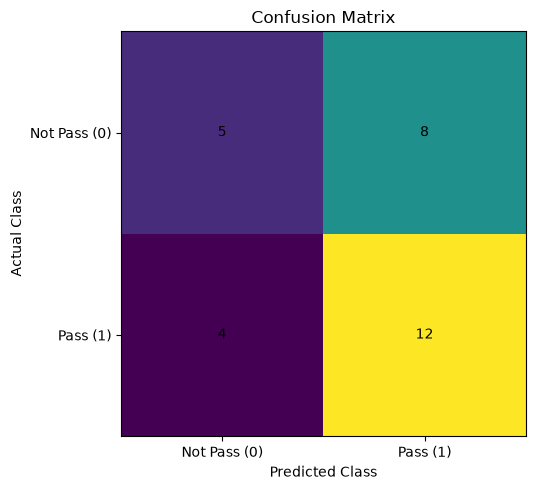

In [16]:
# Visualize the Confusion Matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Not Pass (0)", "Pass (1)"])
plt.yticks([0, 1], ["Not Pass (0)", "Pass (1)"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

##### **9.3 Classification Report**

The classification report provides four important values for each class:

- **Precision** → Of the observations predicted as a particular class, how many actually belong to that class?
- **Recall** → Of the observations that actually belong to a particular class, how many did the model correctly identify?
- **F1-score** → A combined measure of precision and recall.
- **Support** → The number of actual observations belonging to each class.

For this notebook:

- `0` represents **Not Pass**
- `1` represents **Pass**

Therefore, precision and recall should always be interpreted in relation to the class being evaluated.

In [17]:
# Generate the Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Pass", "Pass"]
    )
)

              precision    recall  f1-score   support

    Not Pass       0.56      0.38      0.45        13
        Pass       0.60      0.75      0.67        16

    accuracy                           0.59        29
   macro avg       0.58      0.57      0.56        29
weighted avg       0.58      0.59      0.57        29



The classification report provides four important values for each class:

- **Precision** → Of the observations predicted as a particular class, how many actually belong to that class?
- **Recall** → Of the observations that actually belong to a particular class, how many did the model correctly identify?
- **F1-score** → A combined measure of precision and recall.
- **Support** → The number of actual observations belonging to each class.

For this notebook:

- `0` represents **Not Pass**
- `1` represents **Pass**

Therefore, precision and recall should always be interpreted in relation to the class being evaluated.

#### **9.4 Initial Model Interpretation**

The Logistic Regression model achieved an overall **accuracy of 59%** on the test set.

##### **Not Pass Class**

For the **Not Pass** class:

- **Precision = 0.56** → When the model predicts a student as Not Pass, it is correct about 56% of the time.
- **Recall = 0.38** → The model correctly identifies only about 38% of the students who actually belong to the Not Pass class.
- **F1-score = 0.45** → The combined performance of precision and recall for the Not Pass class is relatively low.

##### **Pass Class**

For the **Pass** class:

- **Precision = 0.60** → When the model predicts a student as Pass, it is correct about 60% of the time.
- **Recall = 0.75** → The model correctly identifies about 75% of the students who actually belong to the Pass class.
- **F1-score = 0.67** → The model performs better for the Pass class than for the Not Pass class.

##### **Overall Interpretation**

The model performs better at identifying **Pass** students than **Not Pass** students.

The overall accuracy of **59%** indicates that the current Logistic Regression model provides a relatively weak baseline on the test set.

The particularly low **recall of 38% for the Not Pass class** indicates that the model is missing a substantial number of students who actually belong to the Not Pass class.

Therefore, this model should be considered a **baseline model**, and further feature engineering, model selection, or parameter tuning may be required to improve classification performance.

#### **10. Actual vs Predicted Classes**

After generating predictions, we can compare the actual classes from the test set with the classes predicted by the Logistic Regression model.

This comparison helps us see individual predictions and determine whether each prediction was correct.

For this notebook:

- **0** → Not Pass
- **1** → Pass

In [18]:
# Create Actual vs Predicted Results

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

results.head(10)

,Actual,Predicted,Correct
0,1,1,True
1,0,1,False
2,1,1,True
3,0,0,True
4,1,1,True
5,0,0,True
6,1,1,True
7,1,1,True
8,0,1,False
9,0,1,False


In [19]:
# Count Correct Predictions

correct_predictions = results["Correct"].sum()
total_predictions = len(results)

print("Correct Predictions:", correct_predictions)
print("Total Predictions  :", total_predictions)

Correct Predictions: 17
Total Predictions  : 29


In [20]:
# Convert Numerical Classes to Readable Labels

results["Actual Label"] = results["Actual"].map({
    0: "Not Pass",
    1: "Pass"
})

results["Predicted Label"] = results["Predicted"].map({
    0: "Not Pass",
    1: "Pass"
})

results[
    [
        "Actual Label",
        "Predicted Label",
        "Correct"
    ]
].head(10)

,Actual Label,Predicted Label,Correct
0,Pass,Pass,True
1,Not Pass,Pass,False
2,Pass,Pass,True
3,Not Pass,Not Pass,True
4,Pass,Pass,True
5,Not Pass,Not Pass,True
6,Pass,Pass,True
7,Pass,Pass,True
8,Not Pass,Pass,False
9,Not Pass,Pass,False


#### **11. Save the Complete Machine Learning Pipeline**

After training and evaluating the model, we can save the complete Machine Learning Pipeline for future use.

We will save the entire Pipeline rather than saving only the Logistic Regression classifier.

The saved Pipeline contains:

- `StandardScaler` for numerical features
- `OneHotEncoder` for categorical features
- `LogisticRegression` for classification

This is important because future data must go through the **same preprocessing steps** before making predictions.

The saved Pipeline can later be loaded and used directly with new raw data.

In [21]:
# Save the Complete Machine Learning Pipeline

joblib.dump(
    model,
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression Pipeline saved successfully.")

Logistic Regression Pipeline saved successfully.


#### **12. Load and Verify the Saved Machine Learning Pipeline**

After saving the trained Pipeline, we can load it again using `joblib`.

We will then use the loaded Pipeline to make predictions on the same test data.

Finally, we will compare the predictions from the original Pipeline with the predictions from the loaded Pipeline.

If both sets of predictions are identical, we can confirm that the saved Pipeline was loaded successfully and retains the trained preprocessing and classification steps.

In [22]:
# Load the Saved Machine Learning Pipeline

loaded_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression Pipeline loaded successfully.")

Logistic Regression Pipeline loaded successfully.


##### **12.1 Make Predictions Using the Loaded Pipeline**

We can now use the loaded Pipeline to make predictions on the test data.

Because the preprocessing steps were saved together with the Logistic Regression model, we do not need to manually scale or encode the test data again.

In [23]:
# Make Predictions Using the Loaded Pipeline

y_pred_loaded = loaded_model.predict(X_test)

y_pred_loaded[:10]

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])

##### **12.2 Verify the Loaded Pipeline**

The original trained Pipeline and the loaded Pipeline should produce the same predictions when given the same test data.

We will use `np.array_equal()` to compare the two prediction arrays.

If the result is `True`, the predictions are identical.

In [24]:
# Compare Original and Loaded Predictions

predictions_match = np.array_equal(
    y_pred,
    y_pred_loaded
)

print("Predictions match:", predictions_match)

Predictions match: True


## 🎉 Congratulations!

You have successfully completed your **Logistic Regression Machine Learning notebook**.

---

### Machine Learning Workflow

```text
Dataset
   │
   ▼
Data Cleaning
   │
   ▼
Exploratory Data Analysis (EDA)
   │
   ▼
Feature Engineering
   │
   ▼
Train-Test Split
   │
   ▼
Preprocessing
   │
   ▼
Model Training
   │
   ▼
Prediction
   │
   ▼
Model Evaluation
   │
   ▼
Save & Load Pipeline